In [1]:
import numpy as np
import numpy.lib.recfunctions as recfun
from pathlib import Path
from plyfile import PlyData, PlyElement
import matplotlib.pyplot as plt

from matplotlib import cm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torchmetrics.classification import BinaryF1Score, BinaryPrecision, BinaryRecall, BinaryMatthewsCorrCoef, BinaryJaccardIndex, BinaryAccuracy

import torchsummary

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [3]:
# We start with loading the .ssm data in this cell to keep the data loaded in the following
def load_full_dataset(dataset='Train'):
    # 1) Path Definition
    # base directory for the chosen dataset
    base_path = Path('../data/Challenge-ABC') / dataset
    if not base_path.exists(): # verification
        print(f"Error: Dataset folder {base_path} not found, check 'dataset' argument.")
        return None
    ssm_dir = base_path / 'SSM_Challenge-ABC'
    lb_dir = base_path / 'lb'

    X_list = []
    y_list = []

    ssm_files = list(ssm_dir.glob('*.ssm'))
    total_files = len(ssm_files)

    for i, ssm_file in enumerate(ssm_files, 1):
        file_id = ssm_file.stem
        lb_file = lb_dir / f"{file_id}.lb"

        # check that the labels file exists
        if not lb_file.exists():
            print(f"Error: Didn't find labels file for {file_id}.ply -> ignored.")
            continue

        features = np.loadtxt(ssm_file, skiprows=5, dtype='float32').reshape(-1, 20, 16)
        labels = np.loadtxt(lb_file, dtype='int')

        if len(labels) == len(features):
            X_list.append(features)
            y_list.append(labels)
        else:
            print(f"Error: Dimension error for {file_id} -> ignored.")

        if i % 20 == 0:
            print(f"Loading : {i}/{total_files} files...")

    X = np.vstack(X_list)
    y = np.concatenate(y_list)    
    
    return X, y

print("Train dataset loading...")
X_train, y_train = load_full_dataset('Train')
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

print("\nValidation dataset loading...")
X_val, y_val = load_full_dataset('Validation')
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")


Train dataset loading...
Loading : 20/198 files...
Loading : 40/198 files...
Loading : 60/198 files...
Loading : 80/198 files...
Loading : 100/198 files...
Loading : 120/198 files...
Loading : 140/198 files...
Loading : 160/198 files...
Loading : 180/198 files...
X_train shape: (3174768, 20, 16)
y_train shape: (3174768,)

Validation dataset loading...
Loading : 20/50 files...
Loading : 40/50 files...
X_val shape: (690211, 20, 16)
y_val shape: (690211,)


In [4]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

print(type(X_train))
print(type(y_train))
print(type(X_val))
print(type(y_val))

# Transform numpy's arrays to torch tensors:
X_train = torch.tensor(X_train).to(torch.float)
y_train = torch.tensor(y_train)
X_val = torch.tensor(X_val).to(torch.float)
y_val = torch.tensor(y_val)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)


X_train shape: (3174768, 20, 16)
y_train shape: (3174768,)
X_val shape: (690211, 20, 16)
y_val shape: (690211,)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
torch.Size([3174768, 20, 16]) torch.Size([3174768])
torch.Size([690211, 20, 16]) torch.Size([690211])


In [5]:
class MLP(nn.Module):
    def __init__(self, num_hidden_1=64, num_hidden_2=64):
        super(MLP, self).__init__()
        self.layer_1 = torch.nn.Linear(320, num_hidden_1)
        self.layer_2 = torch.nn.Linear(num_hidden_1, num_hidden_2)
        self.layer_3 = torch.nn.Linear(num_hidden_2, 2)
        self.num_hidden_1 = num_hidden_1
        self.num_hidden_2 = num_hidden_2

    def forward(self, x):
        # Flatten the input from [batch_size, 20, 16] to [batch_size, 320]
        x = x.view(x.size(0), -1)

        # 1st layer
        out = self.layer_1(x)
        #out = torch.tanh(out) 
        out = torch.sigmoid(out)
        
        # 2nd layer
        out = self.layer_2(out)
        out = torch.sigmoid(out)

        # 3rd/output layer
        out = self.layer_3(out)
        return out

In [6]:
# Check paramters number
model = MLP().to(device)

print(torchsummary.summary(model,input_size=(320,)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 64]          20,544
            Linear-2                   [-1, 64]           4,160
            Linear-3                    [-1, 2]             130
Total params: 24,834
Trainable params: 24,834
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.09
Estimated Total Size (MB): 0.10
----------------------------------------------------------------
None


In [7]:
# Train Function
def train_mlp_model(X_train, y_train, X_val, y_val, nb_epochs=50, batch_size=1024, lr=0.01, device='cpu'):
    print(f"Training on device: {device}")
    model = MLP().to(device)
    X_train_gpu = X_train.to(device)
    y_train_gpu = y_train.to(device)
    X_val_gpu = X_val.to(device)
    y_val_gpu = y_val.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    #optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    
    # --- Metrics ---
    # Dictionnary to store the complete history
    history = {
        'train_loss': [], 'val_loss': [], 'val_acc': [],
        'val_precision': [], 'val_recall': [], 'val_f1': [], 
        'val_mcc': [], 'val_iou': []
    }

    f1_metric = BinaryF1Score().to(device)
    precision_metric = BinaryPrecision().to(device)
    recall_metric = BinaryRecall().to(device)
    mcc_metric = BinaryMatthewsCorrCoef().to(device)
    iou_metric = BinaryJaccardIndex().to(device)
    acc_metric = BinaryAccuracy().to(device)
    
    print("Start of training...")
    
    for epoch in range(1, nb_epochs + 1):

        # --- Training Phase ---
        model.train()
        running_train_loss = 0.0
        
        # Create random permutation of indexes to shuffle the dataset at each epoch withour copying the whole dataset 
        idx = torch.randperm(X_train_gpu.size(0), device=device)

        # Loop over the dataset but instead of copying and shuffling the whole dataset, we work on the indexes 
        # so we slice only the indexes and pick the data directly from the original tensor based on the shuffled indexes
        for i in range(0, X_train_gpu.size(0), batch_size):
            # extract only the indexes for the current batch
            batch_idx = idx[i : i + batch_size]

            # pick the batch data from the data tensor 
            inputs = X_train_gpu[batch_idx]
            labels = y_train_gpu[batch_idx]

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item() * inputs.size(0)   
            
        epoch_train_loss = running_train_loss / X_train_gpu.size(0)
        history['train_loss'].append(epoch_train_loss)

        # --- Validation Phase ---
        model.eval()
        running_val_loss = 0.0

        f1_metric.reset()
        precision_metric.reset()
        recall_metric.reset()
        mcc_metric.reset()
        iou_metric.reset()
        acc_metric.reset()

        with torch.no_grad():
            # same idea but without shuffling and no need to compute gradients
            for i in range(0, X_val_gpu.size(0), batch_size):
                inputs = X_val_gpu[i : i + batch_size]
                labels = y_val_gpu[i : i + batch_size]
      
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)

                _, predicted = torch.max(outputs, 1)

                f1_metric.update(predicted, labels)
                precision_metric.update(predicted, labels)
                recall_metric.update(predicted, labels)
                mcc_metric.update(predicted, labels)
                iou_metric.update(predicted, labels)
                acc_metric.update(predicted, labels)
                
        epoch_val_loss = running_val_loss / X_val_gpu.size(0)
        history['val_loss'].append(epoch_val_loss)
        
        
        # --- Compute Evaluation Metrics ---
        val_prec = precision_metric.compute().item()
        val_rec = recall_metric.compute().item()
        val_f1 = f1_metric.compute().item()
        val_mcc = mcc_metric.compute().item()
        val_iou =  iou_metric.compute().item()
        val_acc = acc_metric.compute().item() * 100.0
        
        history['val_acc'].append(val_acc)
        history['val_precision'].append(val_prec)
        history['val_recall'].append(val_rec)
        history['val_f1'].append(val_f1)
        history['val_mcc'].append(val_mcc)
        history['val_iou'].append(val_iou)

        print(f"Epoch [{epoch}/{nb_epochs}] | T.Loss: {epoch_train_loss:.4f} | V.Loss: {epoch_val_loss:.4f} | F1: {val_f1:.4f} | MCC: {val_mcc:.4f}")

    # Free VRAM data 
    del X_train_gpu, y_train_gpu, X_val_gpu, y_val_gpu, f1_metric, precision_metric, recall_metric, mcc_metric, iou_metric
    torch.cuda.empty_cache()
    
    return history, model

In [ ]:
metrics_history, model = train_mlp_model(X_train, y_train, X_val, y_val, nb_epochs=100, batch_size=4096, device=device)

Training on device: cuda
Start of training...
Epoch [1/20] | T.Loss: 0.0254 | V.Loss: 0.0217 | F1: 0.9443 | MCC: 0.9410
Epoch [2/20] | T.Loss: 0.0091 | V.Loss: 0.0195 | F1: 0.9484 | MCC: 0.9457
Epoch [3/20] | T.Loss: 0.0093 | V.Loss: 0.0205 | F1: 0.9562 | MCC: 0.9538
Epoch [4/20] | T.Loss: 0.0071 | V.Loss: 0.0186 | F1: 0.9576 | MCC: 0.9550
Epoch [5/20] | T.Loss: 0.0073 | V.Loss: 0.0308 | F1: 0.9276 | MCC: 0.9249
Epoch [6/20] | T.Loss: 0.0060 | V.Loss: 0.0224 | F1: 0.9495 | MCC: 0.9471
Epoch [7/20] | T.Loss: 0.0053 | V.Loss: 0.0296 | F1: 0.9327 | MCC: 0.9303
Epoch [8/20] | T.Loss: 0.0085 | V.Loss: 0.0235 | F1: 0.9410 | MCC: 0.9384
Epoch [9/20] | T.Loss: 0.0066 | V.Loss: 0.0211 | F1: 0.9685 | MCC: 0.9666
Epoch [10/20] | T.Loss: 0.0052 | V.Loss: 0.0393 | F1: 0.9446 | MCC: 0.9420
Epoch [11/20] | T.Loss: 0.0052 | V.Loss: 0.0180 | F1: 0.9721 | MCC: 0.9704
Epoch [12/20] | T.Loss: 0.0044 | V.Loss: 0.0297 | F1: 0.9515 | MCC: 0.9491
Epoch [13/20] | T.Loss: 0.0042 | V.Loss: 0.0192 | F1: 0.9712 | 

In [9]:
print(f"F1-scores:\n {metrics_history['val_f1']}")
print(f"Precision:\n {metrics_history['val_precision']}")
print(f"Recall:\n {metrics_history['val_recall']}")
print(f"MCC:\n {metrics_history['val_mcc']}")
print(f"IoU:\n {metrics_history['val_iou']}")

F1-scores:
 [0.9443115592002869, 0.9484456777572632, 0.956231415271759, 0.9575921893119812, 0.9275933504104614, 0.9494686126708984, 0.9326918125152588, 0.9409577250480652, 0.9684966206550598, 0.9446282982826233, 0.9720650911331177, 0.9515060186386108, 0.9711997509002686, 0.9639446139335632, 0.9709728360176086, 0.9701368808746338, 0.9465907216072083, 0.9433903098106384, 0.9562787413597107, 0.9629884362220764]
Precision:
 [0.9582434296607971, 0.9721829295158386, 0.9735325574874878, 0.9624785780906677, 0.9801438450813293, 0.984309732913971, 0.9859640598297119, 0.9827005863189697, 0.9778292179107666, 0.9802301526069641, 0.9799001216888428, 0.9825680255889893, 0.9868929386138916, 0.9833160638809204, 0.9857348203659058, 0.976859450340271, 0.9815439581871033, 0.9862052202224731, 0.9884457588195801, 0.9845203757286072]
Recall:
 [0.9307790398597717, 0.9258400201797485, 0.9395345449447632, 0.9527550935745239, 0.8803911209106445, 0.9170096516609192, 0.8848811388015747, 0.9026166796684265, 0.95934

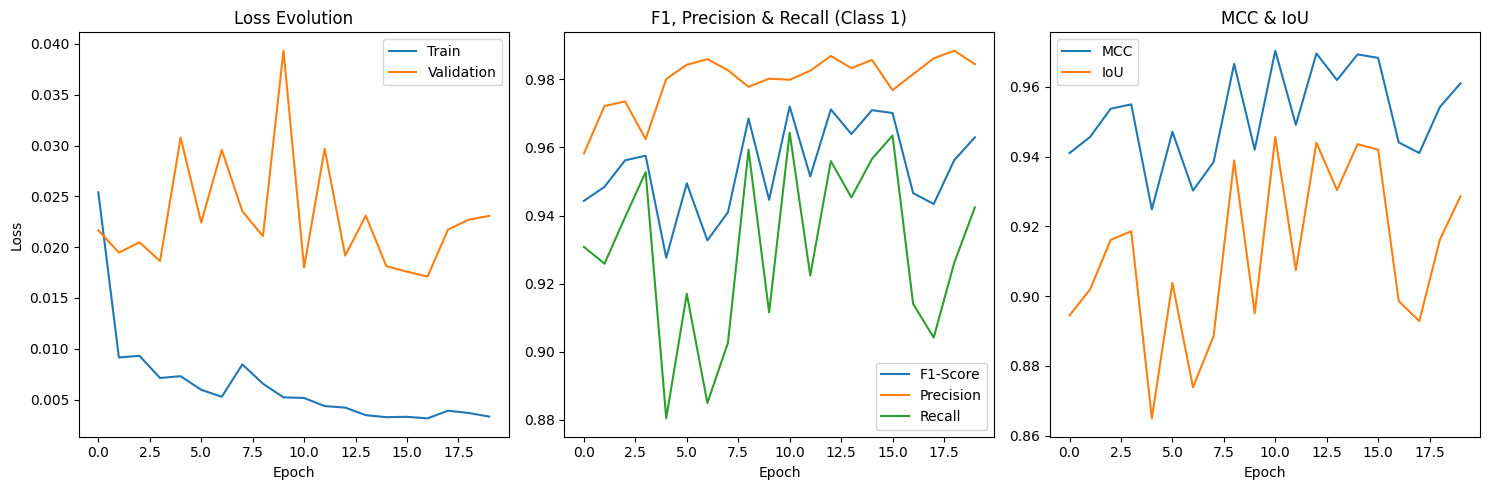

In [10]:
plt.figure(figsize=(15, 5))

# Loss
plt.subplot(1, 3, 1)
plt.title("Loss Evolution")
plt.plot(metrics_history['train_loss'], label="Train")
plt.plot(metrics_history['val_loss'], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# F1-score, Precision, Recall
plt.subplot(1, 3, 2)
plt.title("F1, Precision & Recall (Class 1)")
plt.plot(metrics_history['val_f1'], label="F1-Score")
plt.plot(metrics_history['val_precision'], label="Precision")
plt.plot(metrics_history['val_recall'], label="Recall")
plt.xlabel("Epoch")
plt.legend()

# MCC and IoU
plt.subplot(1, 3, 3)
plt.title("MCC & IoU")
plt.plot(metrics_history['val_mcc'], label="MCC")
plt.plot(metrics_history['val_iou'], label="IoU")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
def generate_prediction_ply(file_id, model, dataset_type='Validation', device='cpu'):
    # Path definitions
    base_dir = Path(f'../data/Challenge-ABC/{dataset_type}')
    ply_file = base_dir / f'ply/{file_id}.ply'
    ssm_file = base_dir / f'SSM_Challenge-ABC/{file_id}.ssm'
    lb_file = base_dir / f'lb/{file_id}.lb'
    
    out_dir = base_dir / 'predictions'
    out_dir.mkdir(exist_ok=True)
    out_file = out_dir / f'{file_id}_pred.ply'

    if not ply_file.exists():
        print(f"Error : The file {ply_file}.ply does not exist.")
        return

    # Charging PLY geometry data
    ply_data = PlyData.read(ply_file)
    vertex_data = ply_data.elements[0].data

    # Charging labels data
    labels = np.loadtxt(lb_file, dtype='int')

    # SSM Descriptors loading 
    features = np.loadtxt(ssm_file, skiprows=5, dtype='float32').reshape(-1, 20, 16)

    # Inference with the trained model
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(features).to(device)
        outputs = model(X_tensor)
        
        # get the predicted class back to CPU
        _, preds = torch.max(outputs, 1)
        predictions = preds.cpu().numpy().astype('int')

    # Create the new vertex_data which appends labels field to already existing fields  
    new_vertex_data = recfun.append_fields(
        vertex_data, 
        names=['label', 'pred'], 
        data=[labels,predictions], 
        dtypes=['i4', 'i4'], 
        usemask=False
        )

    # write the new file
    new_vertex_element = PlyElement.describe(new_vertex_data, 'vertex')
    PlyData([new_vertex_element]).write(str(out_file))

    
    #print(f"File successfuly generated: {out_file}")
    print(f"-> File id: {file_id} | Total points : {len(predictions)} | Real edges : {np.sum(labels)} | Predicted edges : {np.sum(predictions)}")


generate_prediction_ply('0353', model, device=device)
generate_prediction_ply('0713', model, device=device)
generate_prediction_ply('1612', model, device=device)
generate_prediction_ply('1813', model, device=device)

-> File id: 0353 | Total points : 34340 | Real edges : 1552 | Predicted edges : 1605
-> File id: 0713 | Total points : 1004 | Real edges : 880 | Predicted edges : 3
-> File id: 1612 | Total points : 1798 | Real edges : 428 | Predicted edges : 428
-> File id: 1813 | Total points : 17117 | Real edges : 786 | Predicted edges : 786


In [17]:
def batch_generate_predictions(model, dataset_type='Validation', device='cpu'):
    # Path definitions
    base_dir = Path(f'../data/Challenge-ABC/{dataset_type}')
    ssm_dir = base_dir / 'SSM_Challenge-ABC'
    
    # .ssm file listing
    ssm_files = list(ssm_dir.glob('*.ssm'))
    total_files = len(ssm_files)

    if total_files == 0:
        print(f"Error : No files found in {ssm_dir}")
        return
    

    print(f"Beginning inference on the {total_files} models of the {dataset_type} set...")
    
    for i, ssm_file in enumerate(ssm_files, 1):
        file_id = ssm_file.stem
        print(f"[{i:02d}/{total_files}] Processing {file_id}...")
        generate_prediction_ply(file_id, model, dataset_type=dataset_type, device=device)
        
    print("\nCompleted !")

batch_generate_predictions(model, device=device)

Beginning inference on the 50 models of the Validation set...
[01/50] Processing 2192...
-> File id: 2192 | Total points : 6738 | Real edges : 88 | Predicted edges : 88
[02/50] Processing 2507...
-> File id: 2507 | Total points : 25136 | Real edges : 1156 | Predicted edges : 1095
[03/50] Processing 2139...
-> File id: 2139 | Total points : 18826 | Real edges : 240 | Predicted edges : 245
[04/50] Processing 1813...
-> File id: 1813 | Total points : 17117 | Real edges : 786 | Predicted edges : 786
[05/50] Processing 2738...
-> File id: 2738 | Total points : 4867 | Real edges : 472 | Predicted edges : 472
[06/50] Processing 1258...
-> File id: 1258 | Total points : 2327 | Real edges : 30 | Predicted edges : 30
[07/50] Processing 1155...
-> File id: 1155 | Total points : 16623 | Real edges : 990 | Predicted edges : 989
[08/50] Processing 0844...
-> File id: 0844 | Total points : 10371 | Real edges : 854 | Predicted edges : 849
[09/50] Processing 0277...
-> File id: 0277 | Total points : 15